In [1]:
import geopandas as gpd
from shapely.geometry import MultiPolygon
import pandas as pd
from shapely import wkt
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from equi7grid_lite import Equi7Grid
from dotenv import load_dotenv
import os
from pathlib import Path

# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

In [18]:
def get_region_shape(path, region_id):
    
    usa = gpd.read_file(path)
    country = usa[usa.REGION == region_id]
    
    region = country.explode()[0:1] 

    return region
    

In [2]:
def generate_equi7_grid(usa_filepath, resolution, pixel_size, region_id, output_shapefile):
    size = resolution * pixel_size
    print(f"Resolution: {resolution}, Pixel Size: {pixel_size}, Minimum Grid Size: {size}")
    
    # Initialize the Equi7 grid system
    grid_system = Equi7Grid(min_grid_size=size)
    
    # Load and filter the USA shapefile
    usa = gpd.read_file(usa_filepath)
    country = usa[usa['REGION'] == region_id]
    region = country.explode().reset_index(drop=True)
    
    if len(region) == 0:
        raise ValueError(f"No region found with ID {region_id}")
    
    # Ensure 'region' is a GeoDataFrame
    if not isinstance(region, gpd.GeoDataFrame):
        region = gpd.GeoDataFrame(region, geometry='geometry')
    
    # Generate the Equi7 grid
    print("Generating grid...")
    grid = grid_system.create_grid(
        level=0,
        zone="NA",
        mask=region  # Ensure 'region' is a GeoDataFrame with CRS
    )
    
    # Plot and save the grid boundaries
    ax = grid.boundary.plot()
    plt.title(f'Equi7 Grid Boundaries Region {region_id}')
    plt.savefig(f"{output_shapefile.replace('.shp', '.png')}")
    plt.show()
    
    # Save the grid to shapefile
    grid.to_file(output_shapefile)
    print(f"Grid saved to {output_shapefile}")

    return grid


In [29]:
def create_convex_hulls(refdm, ids, output_path):
    """
    Create and save convex hulls from REFDM data and USDA polygon IDs by 
    spatially joining and generating convex hulls for each USDA_IDX.

    Parameters:
    - refdm_path: Path to the REFDM shapefile.
    - ids_path: Path to the USDA polygon IDs shapefile.
    - output_path: Path to save the resulting convex hulls shapefile.

    Returns:
    - convex_hulls_gdf: A GeoDataFrame containing the convex hulls.
    """
    

    # Step 2: Dissolve REFDM geometries by 'USDA_IDX'
    dissolved_refdm = refdm[['IDX_D', 'geometry']].dissolve(by='IDX_D').reset_index()
    print(f"Number of dissolved geometries: {len(dissolved_refdm)}")
    
    # Step 3: Spatial join between dissolved REFDM geometries and USDA IDs
    merged_gdf = gpd.sjoin(dissolved_refdm, ids, how='left', predicate='intersects', on_attribute=['IDX_D'])
    
    # Step 4: Group merged geometries by 'USDA_IDX' and combine them using unary union
    merged_geometries = merged_gdf.groupby('IDX_D')['geometry'].apply(lambda x: x.unary_union)
    
    # Step 5: Create convex hulls for each grouped geometry
    convex_hulls = merged_geometries.apply(lambda geom: MultiPolygon([geom.convex_hull]))
    
    # Step 6: Create a new GeoDataFrame for the convex hulls with the same CRS as REFDM
    convex_hulls_gdf = gpd.GeoDataFrame(geometry=convex_hulls, crs=refdm.crs).reset_index()
    
    # Step 7: Save convex hulls to the specified shapefile path
    convex_hulls_gdf.to_file(output_path)
    print(f"Convex hulls saved to {output_path}")
    
    return convex_hulls_gdf

In [26]:
def intersect_grid(convex_hulls_gdf, grid_gdf, output_shapefile_path, output_figure_path, target_crs, region=None, region_id=None):
    """
    Perform spatial join between convex hulls and grid, plot, and save the results.

    Parameters:
    - convex_hulls_gdf: GeoDataFrame of convex hulls.
    - grid_gdf: GeoDataFrame of grid.
    - output_shapefile_path: File path to save the intersected grid as a shapefile.
    - output_figure_path: File path to save the figure as an image.
    - target_crs: Target Coordinate Reference System (CRS) to project geometries.
    - region: Optional GeoDataFrame for a specific region boundary (optional).
    - region_id: ID of the region to be displayed in the plot title (optional).

    Returns:
    - intersected_gdf_equi7: GeoDataFrame of intersected grids with convex hulls.
    """
    # Perform spatial join between the grid and convex hulls
    intersected_gdf_equi7 = gpd.sjoin(grid_gdf, convex_hulls_gdf, how='inner', predicate='intersects')
    
    # Clean the intersected data
    intersected_gdf_equi7 = (
        intersected_gdf_equi7
        .drop(columns=['index_right', 'IDX_D', 'level', 'land', 'zone'])
        .drop_duplicates()
        .reset_index(drop=True)
    )
    
    # Save the intersected GeoDataFrame as a shapefile
    intersected_gdf_equi7.to_file(output_shapefile_path)
    print(f"Intersected grids saved to: {output_shapefile_path}")
    
    # Plot intersected geometries and region boundary (if provided)
    fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed
    
    # Plot the intersected grids
    intersected_gdf_equi7.boundary.plot(
        ax=ax, color='black', linewidth=0.6, linestyle='-', zorder=2,
        label=f'Intersected Grids ({len(intersected_gdf_equi7)})'
    )
    
    # If region is provided, plot its boundary
    if region is not None:
        region = region.to_crs(target_crs)
        region.boundary.plot(
            ax=ax, color='red', linewidth=0.5, linestyle='--', zorder=3,
            label=f'Region {region_id} Boundary'
        )
    
    # Customize plot appearance
    ax.set_title(f'Intersected Grids with EQUI7 NA Grid and Region {region_id} Boundary', fontsize=18, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_aspect('equal')  # Keep aspect ratio
    
    # Add legend
    ax.legend(loc='upper left', fontsize=12)
    
    # Save the plot as an image
    plt.savefig(output_figure_path, dpi=300)
    print(f"Plot saved to: {output_figure_path}")
    
    # Display the plot
    plt.show()
    
    return intersected_gdf_equi7


Equi7 grids folder: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids/
Loading REFDM shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//radar_results/radar_enhanced_forest_disturbance_mapping_region_08.shp
Loading USDA IDs shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//region08_dca_filtered_ids_usda_polygons.shp

Generating the Equi7 grid...
Resolution: 10, Pixel Size: 512, Minimum Grid Size: 5120
Generating grid...


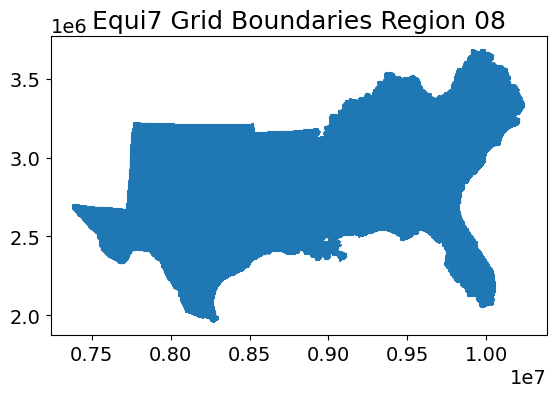

Grid saved to /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids//grid_equi7_10_512_region_08.shp
Grid generation completed in 631.86 seconds.
Grid saved to: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids//grid_equi7_10_512_region_08.shp

Creating convex hulls from REFDM and USDA polygons...
Number of dissolved geometries: 10334
Index(['IDX_D', 'geometry', 'index_right', 'ID_E', 'DCA_ID', 'SURVEY_Y',
       'REGION_ID', 'DA_C_USDA', 'ID_O', 'O_Year', 'O_DCA_ID', 'O_Y_diff',
       'area_km2'],
      dtype='object')


/tmp/ipykernel_93124/573104551.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geometries = merged_gdf.groupby('IDX_D')['geometry'].apply(lambda x: x.unary_union)


Convex hulls saved to /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//radar_results/convex_hulls_refdm_region_08_epsg.shp
Convex hull creation completed in 346.89 seconds.
Convex hulls saved to: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//radar_results/convex_hulls_refdm_region_08_epsg.shp

Reprojecting convex hulls to CRS: EPSG:27705
Reprojection completed.

Performing spatial intersection between convex hulls and grid...
Intersected grids saved to: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids//grid_equi7_10_512_region_08_intersetion.shp
Plot saved to: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/figures//p1_f4_grid_equi7_10_512_region_08_intersetion.png


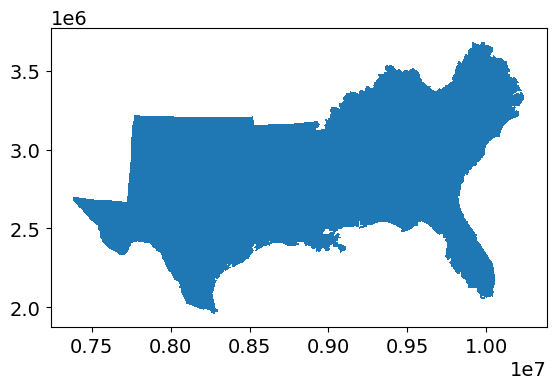

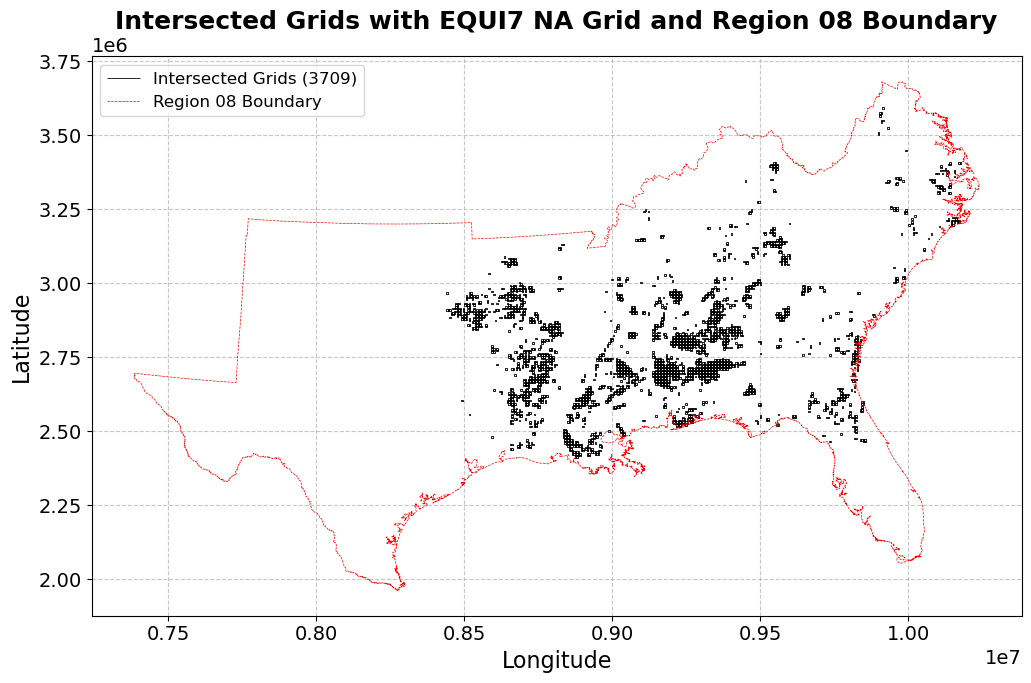

Intersection completed in 2.20 seconds.
Intersected grid saved to: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids//grid_equi7_10_512_region_08_intersetion.shp
Intersection plot saved to: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/figures//p1_f4_grid_equi7_10_512_region_08_intersetion.png

Process completed successfully!



In [30]:
import os
import time
from pathlib import Path
import geopandas as gpd
from tqdm import tqdm  # For progress bars
from dotenv import load_dotenv

# Load environment variables from the .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve environment variables
s2_minicubes_folder = os.getenv('EQUI7_GRIDS')
print(f"Equi7 grids folder: {s2_minicubes_folder}")

# Retrieve the CRS (Coordinate Reference System) for Equi7 NA
equi7_crs = os.getenv('EQUI7_NA_EPSG')

# Ensure the 'REGION' environment variable is set
region = os.getenv('REGION')
if region is None:
    raise ValueError("The 'REGION' environment variable is not set. Please ensure it is defined in the .env file.")

# Format region ID as a two-digit string
region_id = str(region).zfill(2)

# Parameters for the grid
resolution = 10
pixel_size = 512

# Define file paths for shapefiles and output locations
usa_filepath = f"{os.getenv('REGION_SHAPE')}/S_USA.AdministrativeRegion.shp"
ids_path = f"{os.getenv('RESULTS')}/region{region_id}_dca_filtered_ids_usda_polygons.shp"
refdm_path = f"{os.getenv('RESULTS')}/radar_results/radar_enhanced_forest_disturbance_mapping_region_{region_id}.shp"
output_path_grid = f"{s2_minicubes_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}.shp"
output_path_conves = f"{os.getenv('RESULTS')}/radar_results/convex_hulls_refdm_region_{region_id}_epsg_4326.shp"
output_path_intersetion = f"{s2_minicubes_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}_intersetion.shp"
output_figure_intersection = f"{os.getenv('FIGURES')}/p1_f4_grid_equi7_{resolution}_{pixel_size}_region_{region_id}_intersetion.png"

# Function to load region shape from USA boundary shapefile
region_shape = get_region_shape(usa_filepath, region_id=region_id)

# Step 1: Read the REFDM and USDA IDs shapefiles
print(f"Loading REFDM shapefile from: {refdm_path}")
refdm_gdf = gpd.read_file(refdm_path)

print(f"Loading USDA IDs shapefile from: {ids_path}")
ids_gdf = gpd.read_file(ids_path)

# Step 2: Generate the Equi7 grid and save it as a shapefile
print("\nGenerating the Equi7 grid...")
start_time_grid = time.time()  # Start timer for grid creation

grid = generate_equi7_grid(
    usa_filepath=usa_filepath,
    resolution=resolution,
    pixel_size=pixel_size,
    region_id=region_id,
    output_shapefile=output_path_grid
)

# Print the time taken to generate the grid
print(f"Grid generation completed in {time.time() - start_time_grid:.2f} seconds.")
print(f"Grid saved to: {output_path_grid}\n")

# Step 3: Create convex hulls from the REFDM and USDA shapefiles
print("Creating convex hulls from REFDM and USDA polygons...")

# Use tqdm to display a progress bar during convex hull creation
start_time_convex = time.time()  # Start timer for convex hull creation

convex_hulls = create_convex_hulls(refdm_gdf, ids_gdf, output_path_conves)

# Print the time taken for convex hull creation
print(f"Convex hull creation completed in {time.time() - start_time_convex:.2f} seconds.")
print(f"Convex hulls saved to: {output_path_conves}\n")

# Step 4: Reproject the convex hulls to Equi7 CRS
print(f"Reprojecting convex hulls to CRS: {equi7_crs}")
reprojected_convex_hulls = convex_hulls.to_crs(equi7_crs)
print(f"Reprojection completed.\n")

# Plot the grid (optional, can be removed if not needed)
grid.plot()

# Step 5: Intersect the reprojected convex hulls with the grid and save the result
print("Performing spatial intersection between convex hulls and grid...")
start_time_intersection = time.time()

intersected = intersect_grid(
    reprojected_convex_hulls,
    grid,
    output_path_intersetion,
    output_figure_intersection,
    equi7_crs,
    region=region_shape,
    region_id=region_id
)

# Print the time taken for intersection
print(f"Intersection completed in {time.time() - start_time_intersection:.2f} seconds.")
print(f"Intersected grid saved to: {output_path_intersetion}")
print(f"Intersection plot saved to: {output_figure_intersection}\n")

# Print a message indicating the script has finished
print("Process completed successfully!\n")


In [31]:
ids_gdf

,ID_E,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_O,O_Year,O_DCA_ID,O_Y_diff,IDX_D,area_km2,geometry
0,27523,fire,2016,8,8,None,NaN,None,NaN,8_fire_2016_7699,0.473459,"POLYGON ((-88.94417 30.60366, -88.94416 30.603..."
1,27524,wind,2016,8,16,None,NaN,None,NaN,8_wind_2016_7700,0.324117,"POLYGON ((-89.02927 34.93586, -89.02928 34.935..."
2,27525,bark_beetle,2016,8,1,None,NaN,None,NaN,8_bark_beetle_2016_7701,0.062720,"POLYGON ((-83.58988 35.41645, -83.58993 35.416..."
3,27526,bark_beetle,2016,8,1,None,NaN,None,NaN,8_bark_beetle_2016_7702,0.010925,"POLYGON ((-83.70347 35.43516, -83.70356 35.435..."
4,27527,bark_beetle,2016,8,1,None,NaN,None,NaN,8_bark_beetle_2016_7703,0.044889,"POLYGON ((-83.74712 35.43908, -83.74695 35.439..."
...,...,...,...,...,...,...,...,...,...,...,...,...
12302,42949,defoliators,2020,8,2,40452,2019.0,defoliators,-1.0,8_defoliators_2020_26415,3.289071,"MULTIPOLYGON (((-80.62581 37.37002, -80.62669 ..."
12303,43051,defoliators,2020,8,2,40516,2019.0,defoliators,-1.0,8_defoliators_2020_26427,10.858748,"POLYGON ((-91.65263 30.3493, -91.64905 30.3457..."
12304,43126,defoliators,2020,8,2,40249,2019.0,defoliators,-1.0,8_defoliators_2020_26433,3.082422,"POLYGON ((-77.0995 35.93822, -77.10973 35.9378..."
12305,43128,defoliators,2020,8,2,40270,2019.0,defoliators,-1.0,8_defoliators_2020_26434,2.530572,"POLYGON ((-77.12793 35.93405, -77.12752 35.930..."


In [32]:
refdm_gdf

,IDX_D,S1_YEAR,S1_TILE,S1CD_INDEX,ID_E,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,geometry
0,8_wind_2020_21436,2019,E090N030T3,11222,43132,wind,2020,8,16,None,NaN,None,NaN,0.415069,"MULTIPOLYGON (((-88.52817 36.07537, -88.52856 ..."
1,8_wind_2020_21442,2019,E090N030T3,11226,43138,wind,2020,8,16,None,NaN,None,NaN,0.109316,"MULTIPOLYGON (((-87.64262 36.11473, -87.64262 ..."
2,8_bark_beetle_2018_17397,2019,E084N027T3,9102,38138,bark_beetle,2018,8,1,None,NaN,None,NaN,0.073131,"MULTIPOLYGON (((-93.69755 34.09583, -93.69755 ..."
3,8_bark_beetle_2018_17475,2019,E084N027T3,9161,38284,bark_beetle,2018,8,1,None,NaN,None,NaN,0.062851,"MULTIPOLYGON (((-93.39349 34.20451, -93.3933 3..."
4,8_bark_beetle_2018_17476,2019,E084N027T3,9162,38285,bark_beetle,2018,8,1,None,NaN,None,NaN,0.098455,"MULTIPOLYGON (((-93.41802 34.07994, -93.4186 3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23156,8_wind_2019_18942,2018,E087N027T3,10423,40345,wind,2019,8,16,None,NaN,None,NaN,0.028661,"MULTIPOLYGON (((-91.98299 32.98286, -91.98299 ..."
23157,8_wind_2019_19029,2018,E087N027T3,10481,40498,wind,2019,8,16,None,NaN,None,NaN,0.022622,"POLYGON ((-91.91707 33.54125, -91.91687 33.541..."
23158,8_wind_2019_19030,2018,E087N027T3,10482,40499,wind,2019,8,16,None,NaN,None,NaN,0.052120,"MULTIPOLYGON (((-91.91375 33.68772, -91.91375 ..."
23159,8_wind_2019_19034,2018,E087N027T3,10486,40503,wind,2019,8,16,None,NaN,None,NaN,0.000567,"POLYGON ((-91.72417 33.69123, -91.72398 33.691..."


In [49]:
import os
from pathlib import Path
import xarray as xr
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon
from dotenv import load_dotenv
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np

# Load environment variables from .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve environment variables
s2_minicubes_folder = os.getenv('SENTINEL1_TILES')
print(f"Equi7 grids folder: {s2_minicubes_folder}")

# Check if the folder exists
if not os.path.isdir(s2_minicubes_folder):
    raise FileNotFoundError(f"The folder {s2_minicubes_folder} does not exist.")

# Initialize a list to store the results
results = []

# Iterate over files in the directory with a progress bar
for file_name in tqdm(os.listdir(s2_minicubes_folder), desc="Processing files"):
    file_path = os.path.join(s2_minicubes_folder, file_name)
    
    # Skip non-file entries (e.g., directories)
    if not os.path.isfile(file_path):
        continue

    # Check for NetCDF files based on file extension
    if not file_name.endswith('.nc'):
        continue

    # Load the NetCDF file with xarray
    try:
        ds = xr.open_dataset(file_path)
       
        # Extract coordinates and their boundaries
        x_bnds = ds['x_bnds'].values
        y_bnds = ds['y_bnds'].values

        # Get the min/max x and y bounds
        x_min = np.min(x_bnds)
        x_max = np.max(x_bnds)
        y_min = np.min(y_bnds)
        y_max = np.max(y_bnds)

        # Create a polygon from the bounding box
        bounding_box = Polygon([
            (x_min, y_min),  # Bottom-left
            (x_max, y_min),  # Bottom-right
            (x_max, y_max),  # Top-right
            (x_min, y_max),  # Top-left
            (x_min, y_min)   # Close the polygon
        ])

        # Append the filename and bounding box to results
        results.append({
            'filename': file_name,
            'geometry': bounding_box
        })

        print(f"Processed file: {file_name}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
        continue

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Convert DataFrame to GeoDataFrame with the original CRS (assumed EQUI7 here)
# You may need to adjust this CRS depending on your actual data
results_gdf = gpd.GeoDataFrame(results_df, geometry='geometry', crs='EPSG:27705')  # Replace with the correct CRS if different
results_gdf
# # Reproject to EPSG:4326 (WGS 84)
# results_gdf = results_gdf.to_crs(epsg=4326)

# # Save the GeoDataFrame to a file (e.g., GeoJSON)
# output_file = "/path/to/save/reprojected_bounding_boxes.geojson"
# results_gdf.to_file(output_file, driver="GeoJSON")

# # Display the GeoDataFrame
# print("Reprojected GeoDataFrame:")
# print(results_gdf.head())


Equi7 grids folder: /net/projects/forexd/WP1/Data/S1_TILES_R8/s1_change_detection_northamerica/


Processing files:   5%|▍         | 5/102 [00:00<00:02, 44.22it/s]

Processed file: EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3.0_year_2021_cluster_compressed.nc
Processed file: EQUI7_NA020M_E084N030T3_rqatrend_VH_A_thresh_3.0_year_2017_cluster.nc
Processed file: EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
Error reading file EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2019_cluster_compressed.nc: "No variable named 'x_bnds'. Variables on the dataset include ['x', 'y', 'layer']"
Processed file: EQUI7_NA020M_E087N027T3_rqatrend_VH_A_thresh_3.0_year_2020_cluster_compressed.nc
Processed file: EQUI7_NA020M_E099N033T3_rqatrend_VH_A_thresh_3.0_year_2019_cluster_compressed.nc
Processed file: EQUI7_NA020M_E096N027T3_rqatrend_VH_A_thresh_3.0_year_2017_cluster_compressed.nc
Processed file: EQUI7_NA020M_E087N027T3_rqatrend_VH_A_thresh_3.0_year_2017_cluster_compressed.nc


Processing files:  10%|▉         | 10/102 [00:00<00:02, 45.20it/s]

Processed file: EQUI7_NA020M_E096N027T3_rqatrend_VH_A_thresh_3.0_year_2020_cluster_compressed.nc
Processed file: EQUI7_NA020M_E093N030T3_rqatrend_VH_A_thresh_3.0_year_2020_cluster_compressed.nc


...

Processing files:  95%|█████████▌| 97/102 [00:02<00:00, 47.75it/s]

Processed file: EQUI7_NA020M_E099N030T3_rqatrend_VH_A_thresh_3.0_year_2021_cluster_compressed.nc


Processing files: 100%|██████████| 102/102 [00:02<00:00, 45.64it/s]

Processed file: EQUI7_NA020M_E087N024T3_rqatrend_VH_A_thresh_3.0_year_2018_cluster_compressed.nc
Error reading file EQUI7_NA020M_E084N027T3_rqatrend_VH_A_thresh_3.0_year_2021_cluster_compressed.nc: "No variable named 'x_bnds'. Variables on the dataset include ['x', 'y', 'layer']"
Processed file: EQUI7_NA020M_E096N024T3_rqatrend_VH_A_thresh_3.0_year_2018_cluster_compressed.nc
Processed file: EQUI7_NA020M_E099N030T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
Error reading file EQUI7_NA020M_E084N027T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc: "No variable named 'x_bnds'. Variables on the dataset include ['x', 'y', 'layer']"


,filename,geometry
0,EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8700000 3000020, 9000000 3000020, 90..."
1,EQUI7_NA020M_E084N030T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8400000 3000020, 8700000 3000020, 87..."
2,EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8700000 3000020, 9000000 3000020, 90..."
3,EQUI7_NA020M_E087N027T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8700000 2700020, 9000000 2700020, 90..."
4,EQUI7_NA020M_E099N033T3_rqatrend_VH_A_thresh_3...,"POLYGON ((9900000 3300020, 10200000 3300020, 1..."
...,...,...
83,EQUI7_NA020M_E090N030T3_rqatrend_VH_A_thresh_3...,"POLYGON ((9000000 3000020, 9300000 3000020, 93..."
84,EQUI7_NA020M_E099N030T3_rqatrend_VH_A_thresh_3...,"POLYGON ((9900000 3000020, 10200000 3000020, 1..."
85,EQUI7_NA020M_E087N024T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8700000 2400020, 9000000 2400020, 90..."
86,EQUI7_NA020M_E096N024T3_rqatrend_VH_A_thresh_3...,"POLYGON ((9600000 2400020, 9900000 2400020, 99..."


Reprojected GeoDataFrame:


<Axes: >

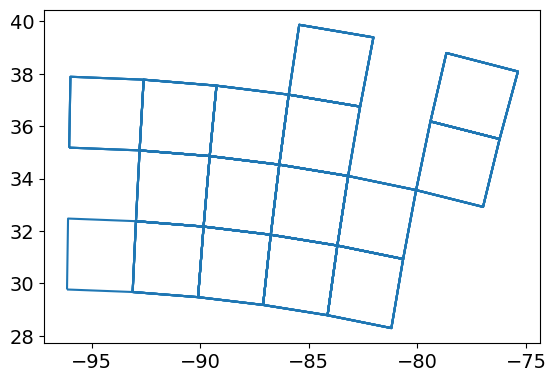

In [54]:
result_path = f"{os.getenv('RESULTS')}/radar_results/s1cd_tiles_bounds_region_{region_id}.shp"
# Reproject to EPSG:4326 (WGS 84)
results_gdf = results_gdf.to_crs(epsg=4326)
results_gdf.to_file(result_path)
# Display the GeoDataFrame
print("Reprojected GeoDataFrame:")
results_gdf.boundary.plot()

In [ ]:
# Create a DataFrame from the results
results_df = pd.DataFrame(results)
# Convert DataFrame to GeoDataFrame
results_gdf = gpd.GeoDataFrame(results_df, geometry='geometry')

# Display the GeoDataFrame
results_gdf


In [ ]:
# Save the results to a shapefile
output_path = f"{os.getenv('RESULTS')}/boundaries_sentinel_1.shp"
results_gdf = gpd.GeoDataFrame(results_df, geometry='geometry')
results_gdf.to_file(output_path)

print(f"Saved boundaries to {output_path}")